### 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dataset/match_winner_dataset.csv")

df.head()

,id,season,city,match_type,team1,team2,toss_winner,toss_decision,venue,team1_win_pct,team2_win_pct,venue_avg_score,winner
0,335982,2008,Bangalore,League,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,M Chinnaswamy Stadium,48.81,52.19,173,Kolkata Knight Riders
1,335983,2008,Chandigarh,League,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Punjab Cricket Association IS Bindra Stadium,45.53,58.23,168,Chennai Super Kings
2,335984,2008,Delhi,League,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,46.00,51.14,162,Delhi Capitals
3,335985,2008,Mumbai,League,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Wankhede Stadium,55.17,48.81,170,Royal Challengers Bengaluru
4,335986,2008,Kolkata,League,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Eden Gardens,52.19,38.67,166,Kolkata Knight Riders


### 2. Dataset Used For ML

In [2]:
print(df.shape)

print(df.columns)

(1090, 13)
Index(['id', 'season', 'city', 'match_type', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'venue', 'team1_win_pct', 'team2_win_pct',
       'venue_avg_score', 'winner'],
      dtype='object')


This dataset was prepared for match winner prediction.
It contains team, venue, toss and historical performance information.

### 1. Feature 1 — Win Percentage Difference

In [3]:
df["win_pct_diff"] = (
    df["team1_win_pct"]
    -
    df["team2_win_pct"]
)

In [4]:
df[
    [
        "team1",
        "team2",
        "team1_win_pct",
        "team2_win_pct",
        "win_pct_diff"
    ]
].head()

,team1,team2,team1_win_pct,team2_win_pct,win_pct_diff
0,Royal Challengers Bengaluru,Kolkata Knight Riders,48.81,52.19,-3.38
1,Punjab Kings,Chennai Super Kings,45.53,58.23,-12.70
2,Delhi Capitals,Rajasthan Royals,46.00,51.14,-5.14
3,Mumbai Indians,Royal Challengers Bengaluru,55.17,48.81,6.36
4,Kolkata Knight Riders,Deccan Chargers,52.19,38.67,13.52


Positive value → Team 1 stronger historically.

Negative value → Team 2 stronger historically.

### 2. Feature 2 — Toss Advantage

In [5]:
df["team1_won_toss"] = (
    df["toss_winner"] == df["team1"]
).astype(int)

In [6]:
df[
    [
        "team1",
        "toss_winner",
        "team1_won_toss"
    ]
].head()

,team1,toss_winner,team1_won_toss
0,Royal Challengers Bengaluru,Royal Challengers Bengaluru,1
1,Punjab Kings,Chennai Super Kings,0
2,Delhi Capitals,Rajasthan Royals,0
3,Mumbai Indians,Mumbai Indians,1
4,Kolkata Knight Riders,Deccan Chargers,0


This feature identifies whether Team 1 won the toss.

1 = Team 1 won the toss
0 = Team 1 lost the toss

### 3. Feature 3 — Chasing Advantage

In [7]:
df["team1_is_chasing"] = (
    (
        (df["toss_winner"] == df["team1"])
        &
        (df["toss_decision"] == "field")
    )
).astype(int)

In [8]:
df[
    [
        "team1",
        "toss_winner",
        "toss_decision",
        "team1_is_chasing"
    ]
].head(10)

,team1,toss_winner,toss_decision,team1_is_chasing
0,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,1
1,Punjab Kings,Chennai Super Kings,bat,0
2,Delhi Capitals,Rajasthan Royals,bat,0
3,Mumbai Indians,Mumbai Indians,bat,0
4,Kolkata Knight Riders,Deccan Chargers,bat,0
5,Rajasthan Royals,Punjab Kings,bat,0
6,Deccan Chargers,Deccan Chargers,bat,0
7,Chennai Super Kings,Mumbai Indians,field,0
8,Deccan Chargers,Rajasthan Royals,field,0
9,Punjab Kings,Mumbai Indians,field,0


This feature identifies whether Team 1 is chasing.

1 = Team 1 is batting second
0 = Team 1 is batting first

### 4. Feature Importance Logic

In [9]:
feature_summary = pd.DataFrame({
    "Feature":[
        "Win Percentage Difference",
        "Toss Advantage",
        "Chasing Indicator",
        "Venue Average Score"
    ],
    "Purpose":[
        "Measures historical strength",
        "Captures toss impact",
        "Captures chasing advantage",
        "Captures venue behavior"
    ]
})

feature_summary

,Feature,Purpose
0,Win Percentage Difference,Measures historical strength
1,Toss Advantage,Captures toss impact
2,Chasing Indicator,Captures chasing advantage
3,Venue Average Score,Captures venue behavior


These engineered features convert raw match data into meaningful inputs that can be used by machine learning models.

### 5. Distribution of Win Percentage Difference

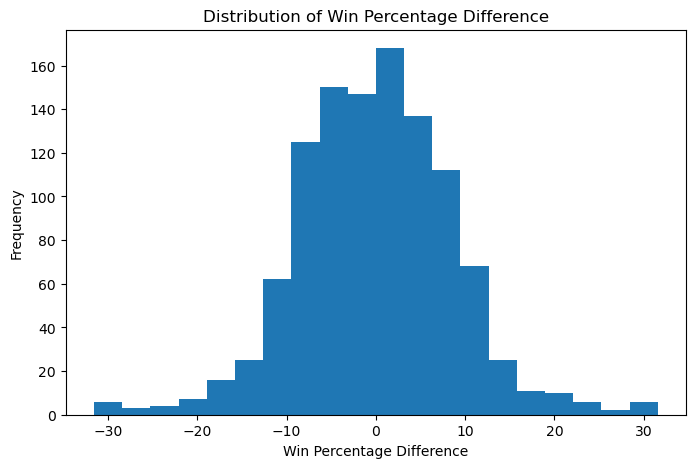

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["win_pct_diff"],
    bins=20
)

plt.title("Distribution of Win Percentage Difference")
plt.xlabel("Win Percentage Difference")
plt.ylabel("Frequency")

plt.show()

This chart shows the distribution of historical strength differences between competing teams.

### 6. Correlation Between Engineered Features

In [11]:
features = [
    "win_pct_diff",
    "team1_won_toss",
    "team1_is_chasing",
    "venue_avg_score"
]

corr = df[features].corr()

corr

,win_pct_diff,team1_won_toss,team1_is_chasing,venue_avg_score
win_pct_diff,1.000000,0.023082,-0.014495,0.104497
team1_won_toss,0.023082,1.000000,0.532244,-0.110023
team1_is_chasing,-0.014495,0.532244,1.000000,-0.049613
venue_avg_score,0.104497,-0.110023,-0.049613,1.000000


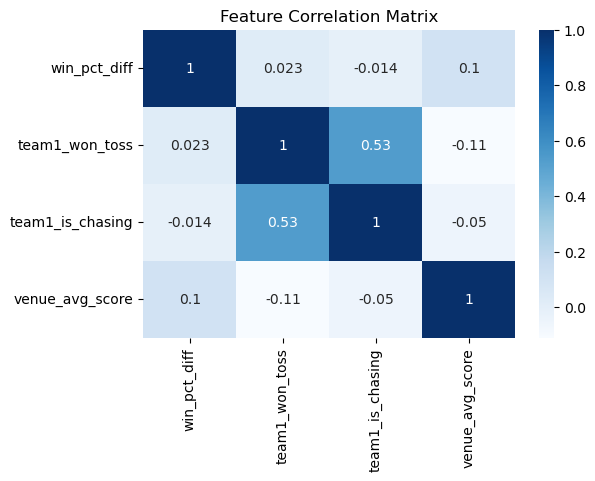

In [12]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation Matrix")

plt.show()

The correlation matrix helps identify relationships between engineered features.

## Feature Engineering Summary

Key Findings:

- Win Percentage Difference captures team strength.
- Toss Advantage measures toss impact.
- Chasing Indicator captures batting-order strategy.
- Venue Average Score represents ground conditions.
- These features were used for Random Forest and XGBoost models.